[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kithhooni-commits/ds-practice/blob/main/%EC%8B%A4%EC%8A%B55/colab_day3.ipynb)

# 실습5 Day 3 — Denoising + Deconvolution

```
Day 1   g = f + n          입력 24.67 dB   노이즈만
Day 2   g = h * f          입력  7.89 dB   흐림만
Day 3   g = h * f + n      입력  8.02 dB   둘 다
```

**3일차 노이즈는 1일차와 파일별로 완전히 동일하다** — `test_deconv_noise/noise_meta.json` 의
종류·σ 가 `test_noise_only` 와 100/100 일치한다. dipole 도 2일차와 같다.
지금까지 만든 것이 그대로 합쳐진다.

## 2일차 답이 무너진다

| | Day 2 | Day 3 |
|---|---|---|
| Wiener K→0 | **109.86** | **−24.24** |
| Wiener 최적 K | — | 14.59 (K=3e-2) |
| 배포 baseline | U-Net 25.59 | **U-Net 25.01** |

역산이 노이즈를 32 dB 증폭한다. K 를 키워 막으면 이번엔 정보를 버려서 14.59 에 그친다.
**고전 기법 단독으로는 딥러닝을 못 이긴다** — 1·2일차와 정반대 상황이다.

## 그래서 나눠서 푼다

```
x₀ = Wiener(g, K)                    2일차 — 흐림을 되돌린다
반복:  z = 디노이저(x)                1일차 — 노이즈를 지운다
      x = (D·G + λZ)/(D² + λ)        물리 제약, 닫힌 해
```

한 번에 다 하려면 K 를 크게 잡아 정보를 버려야 하지만, 나눠서 반복하면 둘 다 살린다.

## 0. 런타임 · Drive

In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
from google.colab import drive
drive.mount("/content/drive")

name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB
Mounted at /content/drive


## 1. 데이터 준비

**3일차용으로 갱신된 dataset** 이 필요하다 (`test_deconv_noise` 포함).
`code_denoising+deconv` zip 에는 배포 베이스라인 체크포인트(13.43M)가 들어 있다.

In [ ]:
import os, zipfile
from pathlib import Path

SEARCH_ROOT = Path("/content/drive/MyDrive")
WORK = Path("/content/data")
DATA_ROOT = None
WANT = ("dataset", "code_denoising+deconv")

WORK.mkdir(parents=True, exist_ok=True)
for z in sorted(p for d in ("*.zip", "*/*.zip") for p in SEARCH_ROOT.glob(d)):
    tag = next((w for w in WANT if z.name.startswith(w)), None)
    if tag is None:
        continue
    print("푸는 중:", z.name)
    with zipfile.ZipFile(z) as f:
        f.extractall(WORK)

def looks_like(p):
    return (p / "train").is_dir() and (p / "test_deconv_noise").is_dir()

if DATA_ROOT is None:
    seen = [WORK] + [p for d in ('*', '*/*') for p in WORK.glob(d) if p.is_dir()]
    seen += [SEARCH_ROOT] + [p for d in ('*', '*/*') for p in SEARCH_ROOT.glob(d) if p.is_dir()]
    cands = [p for p in seen if looks_like(p)]
    if not cands:
        print("WORK 안:", [x.name for x in WORK.iterdir()])
        raise SystemExit("test_deconv_noise 가 있는 dataset 을 못 찾았다. 3일차 zip 인지 확인할 것")
    DATA_ROOT = cands[0]

DATA_ROOT = Path(DATA_ROOT)
os.environ["DS_DATA"] = str(DATA_ROOT)
print("\nDATA_ROOT =", DATA_ROOT)
for sub in ("train", "val", "test_label", "test_deconv_noise"):
    q = DATA_ROOT / sub
    n = len(list(q.glob("**/*.npy"))) if q.exists() else 0
    print(f"{'OK  ' if n else '없음'} {sub:<20} {n:>5} npy")

푸는 중: code_denoising+deconv-20260902T022203Z-1-001.zip
푸는 중: dataset-20260902T022226Z-1-001.zip

DATA_ROOT = /content/data/dataset
OK   train                 7268 npy
OK   val                    100 npy
OK   test_label             100 npy
OK   test_deconv_noise      100 npy


## 2. 코드 받기

In [ ]:
REPO = Path("/content/ds-practice")
if REPO.exists():
    !cd "{REPO}" && git pull --ff-only
else:
    !git clone --depth 1 https://github.com/kithhooni-commits/ds-practice.git "{REPO}"

SRC = REPO / "실습5" / "src" / "deconv"
RUNS = Path("/content/runs")
RUNS.mkdir(exist_ok=True)
!cd "{REPO}" && git log --oneline -1

Cloning into '/content/ds-practice'...
remote: Enumerating objects: 387, done.
remote: Counting objects: 100% (387/387), done.
remote: Compressing objects: 100% (330/330), done.
remote: Total 387 (delta 59), reused 302 (delta 54), pack-reused 0 (from 0)
Receiving objects: 100% (387/387), 59.18 MiB | 48.21 MiB/s, done.
Resolving deltas: 100% (59/59), done.
7256e41 (grafted, HEAD -> main, origin/main, origin/HEAD) day3: 발표용 용어 정리와 예상 질문 21개를 정리한다


## 3. 넘어야 할 선 — 배포 베이스라인과 고전 기법

배포 체크포인트는 End2End U-Net (chans 64, 4 pool, 13.43M, 100 epoch, L2) 이다.
우리 `models.py` 의 `Unet(features=64)` 과 구조가 같아 그대로 불러온다.

In [ ]:
BASE = Path("/content/data/code_denoising+deconv/checkpoint_baseline_best.ckpt")
if not BASE.exists():
    BASE = next(Path("/content/data").rglob("checkpoint_baseline_best.ckpt"))
print("baseline:", BASE)
!cd "{SRC}" && python eval_day3.py --data "{DATA_ROOT}" --ckpt "{BASE}" --wiener

## 4. 학습

`--noise-model challenge` 가 핵심이다. 1일차 4종 노이즈를 **흐림 뒤에** 얹어
`test_deconv_noise` 와 같은 조건을 만든다. 크롭은 하지 않는다 — deconvolution 은
전역 연산이라 조각만 보면 복원에 필요한 정보가 조각 밖에 있다.

| 모델 | 아이디어 | 2일차 성적 |
|---|---|---|
| `unet` | 배포 방식. end-to-end | 28.59 |
| `dcnet` | 신뢰 대역은 G/D 로 못 박고 null cone 만 학습 | 42.93 |
| `unrolled` | 데이터 정합 ↔ 디노이저를 N번 반복 | — |

3일차는 노이즈가 있으므로 `tau` 를 2일차보다 크게 잡는다. 작게 잡으면 1/D 가
노이즈를 증폭한다.

### ① DC-Net — 2일차 최고 구조를 3일차 조건으로

In [ ]:
!cd "{SRC}" && python train_deconv.py \
    --model dcnet --refine unet --features 32 --tau 0.15 \
    --noise-model challenge \
    --epochs 40 --batch 16 --lr 2e-4 --loss charbonnier --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag dcnet_d3

### ② 전개형 — 데이터 정합과 디노이저를 5번 반복

In [ ]:
!cd "{SRC}" && python train_deconv.py \
    --model unrolled --refine unet --features 32 --unroll-iters 5 \
    --noise-model challenge \
    --epochs 40 --batch 8 --lr 2e-4 --loss charbonnier --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag unrolled_d3

### ③ 대조군 — 배포와 같은 end-to-end U-Net (크롭 없이, 우리 레시피로)

In [ ]:
!cd "{SRC}" && python train_deconv.py \
    --model unet --features 64 \
    --noise-model challenge \
    --epochs 60 --batch 8 --lr 2e-4 --loss charbonnier --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag unet_d3

## 5. 평가 — 제출값 산출

`test_deconv_noise` 100장을 `test_label` 로 채점한다. 배포 지표 구현 그대로.

In [ ]:
import glob, json
from pathlib import Path

for ck in sorted(RUNS.glob("*/checkpoints/checkpoint_best.ckpt")):
    print(f"\n{'='*64}\n  {ck.parent.parent.name}\n{'='*64}")
    !cd "{SRC}" && python eval_day3.py --data "{DATA_ROOT}" --ckpt "{ck}"

### 결과 요약 + Drive 저장

In [ ]:
import shutil, json, glob
from pathlib import Path

OUT = Path("/content/drive/MyDrive/실습프로젝트/runs_day3")
OUT.mkdir(parents=True, exist_ok=True)
for r in Path("/content/runs").glob("*"):
    shutil.copytree(r, OUT / r.name, dirs_exist_ok=True)

print(f"\n{'run':<44}{'val PSNR':>10}{'SSIM':>9}")
print("-" * 63)
for h in sorted(glob.glob("/content/runs/*/history.json")):
    d = json.load(open(h))
    b = max(d, key=lambda x: x["val_psnr"])
    print(f'{Path(h).parent.name:<44}{b["val_psnr"]:>10.2f}{b["val_ssim"]:>9.4f}')

## 6. 제출

`challenge_score.xlsx` 에 **성함(팀명) · PSNR · SSIM · Supervised / Self-supervised / Others**
를 적는다. PSNR 은 소수 셋째자리, SSIM 은 넷째자리에서 반올림.

| | PSNR | SSIM | 분류 |
|---|---|---|---|
| 입력 (blur + noise) | 8.02 | −0.0187 | — |
| Wiener 최적 K=3e-2 | 14.59 | 0.4322 | Others |
| 배포 baseline (End2End U-Net) | 25.01 | 0.8149 | Supervised |
| 우리 모델 | ? | ? | Supervised |

## 7. 2차 시도 — 전개형이 ep37 에서 멈춘 뒤

1차 전개형(unet f32, blind)이 **val 25.91 에서 정체**했다. 에폭이 병목이 아니다.
숫자로 확인한 병목은 두 가지다.

- **σ 가 이미지마다 200배 차이난다** (0.0007 ~ 0.13). blind 모델 하나로 덮으려면
  평균에 타협해야 한다. σ<0.05 에서 23.91 dB, σ>=0.10 에서 17.64 dB — 6 dB 차이.
- **용량.** 1일차에서 DRUNet 이 DnCNN 을 2.9 dB 이겼다. 전개형 안에서도 같을 것이다.

**먼저 셀 6(코드 받기)을 다시 실행할 것.** 아래 플래그는 방금 추가된 것이라
`git pull` 없이는 `unrecognized arguments` 가 난다.


In [ ]:
import torch

def is_day1_denoiser(ck):
    """1일차 train.py 가 저장한 디노이저인가.

    1일차: {"model","layers","features","state_dict","epoch","val_psnr","val_ssim"}
    2/3일차 deconv: 위에 더해 {"input","target","unroll_iters","refine",...}

    "input" 이나 "unroll_iters" 가 있으면 deconv 실행이다. 그 가중치는 이미지 영역
    역산을 배운 것이라 측정치 영역 디노이저 자리에 넣어봐야 도움이 안 된다.
    """
    if "input" in ck or "unroll_iters" in ck or "target" in ck:
        return False
    return ck.get("model") == "drunet" and not ck.get("label_free")

CAND = sorted(set(
    glob.glob("/content/drive/MyDrive/**/*.ckpt", recursive=True)
    + glob.glob("/content/runs/**/*.ckpt", recursive=True)))
D1, best = None, -1
print(f"{chr(32)}{'체크포인트':<57}{'val':>8}  판정")
print("-" * 78)
for c in CAND:
    try:
        ck = torch.load(c, map_location="cpu", weights_only=False)
    except Exception:
        continue
    v = ck.get("val_psnr", 0)
    if is_day1_denoiser(ck):
        verdict = "1일차 디노이저"
        if v > best:
            D1, best = c, v
    elif ck.get("model") == "drunet":
        verdict = f"deconv 실행 (input={ck.get('input')}) — 쓰지 않는다"
    else:
        verdict = f"model={ck.get('model')} — 대상 아님"
    print(f"{c[-57:]:<58}{v:>8.2f}  {verdict}")

INIT = f'--init-refine "{D1}"' if D1 else ""
print()
if D1:
    print(f"선택: {D1}  (val {best:.2f} dB)")
else:
    print("1일차 DRUNet 을 못 찾았다 — 무작위 초기화로 진행한다 (그래도 돌아간다).")
    print("1일차 실행의 checkpoint_best.ckpt 를 Drive 에 올리면 훨씬 빨리 수렴한다.")

### ① 주력 — σ 조건화 + DRUNet + 1일차 가중치 warm start

`estimate_sigma` 가 **측정치만 보고** σ 를 읽는다. `|D|<0.02` 인 주파수엔 신호가
실려올 수 없으니 거기 남은 건 전부 노이즈다 (파세발). val 40장 상대오차 중앙값 1.9%.
정답도 `noise_meta.json` 도 쓰지 않는다.

warm start 는 σ 채널을 0 으로 두고 시작하므로 **첫 순간엔 1일차 디노이저와 정확히
같게** 동작하고, 거기서부터 σ 를 쓰는 법을 배운다 (차이 0.00e+00 로 확인).

`checkpoint_best` 는 매 에폭 갱신되니 **중간에 끊어도 쓸 수 있다.**

In [ ]:
!cd "{SRC}" && python train_deconv.py     --model unrolled --refine drunet --features 48 --unroll-iters 4     --sigma-map {INIT}     --noise-model challenge --input measure     --epochs 60 --batch 4 --lr 2e-4 --loss charbonnier --clip-grad 1.0 --workers 8     --data "{DATA_ROOT}" --out "{RUNS}" --tag u_drunet_sig

### ② 대조군 — σ 조건화만 뺀다

①과 이 둘의 차이가 곧 **σ 조건화가 번 점수**다. 발표의 ablation 에 필요하다.
시간이 없으면 이건 건너뛰고 ①을 더 오래 돌려도 된다.

In [ ]:
!cd "{SRC}" && python train_deconv.py     --model unrolled --refine drunet --features 48 --unroll-iters 4     --noise-model challenge --input measure     --epochs 60 --batch 4 --lr 2e-4 --loss charbonnier --clip-grad 1.0 --workers 8     --data "{DATA_ROOT}" --out "{RUNS}" --tag u_drunet_blind

### ③ 방법 B 대조군 — 측정치 영역에서 노이즈만 지우고 Wiener 가 역산

배포 노트북의 방법 B. 노이즈가 흐림 **뒤에** 붙었으므로 측정치 위에서는 백색이고,
그게 디노이저가 가장 잘하는 조건이다. 평가 때 `--sweep-K` 로 K 를 val 에서 고른다.

In [ ]:
!cd "{SRC}" && python train_deconv.py     --model drunet --features 64 --target measure     --noise-model challenge --input measure     --epochs 60 --batch 8 --lr 2e-4 --loss charbonnier --clip-grad 1.0 --workers 8     --data "{DATA_ROOT}" --out "{RUNS}" --tag methodB

## 8. 평가 — 4x self-ensemble 포함

dipole 이 견디는 대칭만 쓴다: **좌우 뒤집기 · 상하 뒤집기 · 180도 회전** (오차 7e-16).
전치와 90도 회전은 B0 방향을 돌려버려 **연산자 자체가 바뀐다** (오차 3.17) — 1일차의
8x self-ensemble 을 그대로 가져오면 오히려 손해다.

K 는 전부 **val 에서** 고른다. test 는 채점에만 쓴다.

In [ ]:
for ck in sorted(RUNS.glob("*/checkpoints/checkpoint_best.ckpt")):
    name = ck.parent.parent.name
    if not any(t in name for t in ("u_drunet_sig", "u_drunet_blind", "methodB")):
        continue
    sweep = "--sweep-K" if "methodB" in name else ""
    print(f"\n{'='*64}\n  {name}\n{'='*64}")
    !cd "{SRC}" && python eval_day3.py --data "{DATA_ROOT}" --ckpt "{ck}" --self-ensemble {sweep}

## 9. 이미지로 확인 — 노트북 안에서 바로 본다

배포 안내가 요구한 것: 학습에 쓴 synthetic 쌍과 test 결과를 **visualize**,
**difference map**, 세부는 **zoom-in**, 어떤 노이즈·이미지에 취약한지 분석.

`figures_day3.py` 가 네 장을 만든다.

| 그림 | 내용 |
|---|---|
| `day3_forward_chain` | clean -> dipole blur -> +noise. 학습 쌍이 어떻게 만들어지는가 |
| `day3_methods_grid` | 노이즈 4종 x 방법별 복원 결과 |
| `day3_diff_zoom` | 정답과 나란히, \|복원-정답\| 맵, 72x72 확대 |
| `day3_weakness` | 노이즈별 성능 + σ 대비 성능 |

대표 이미지는 그 종류의 **σ 중앙값**에 가까운 것을 고른다 — 잘 나온 걸 고르면
발표가 거짓말이 된다.

In [ ]:
# 학습한 모델까지 그림에 넣는다. 돌아간 run 중 val 이 가장 높은 것을 고른다.
import json, torch
from pathlib import Path
from IPython.display import Image, display, Markdown

best_ck, best_val, best_name = None, -1, ""
for ck in sorted(RUNS.glob("*/checkpoints/checkpoint_best.ckpt")):
    v = torch.load(ck, map_location="cpu", weights_only=False).get("val_psnr", -1)
    if v > best_val:
        best_ck, best_val, best_name = ck, v, ck.parent.parent.name
print(f"그림에 넣을 모델: {best_name}  (val {best_val:.2f} dB)")

# --target measure 로 학습한 모델은 출력에 Wiener 를 한 번 더 걸어야 한다
cfg = json.loads((best_ck.parent.parent / "config.json").read_text(encoding="utf-8"))       if (best_ck.parent.parent / "config.json").exists() else {}
POST = "--post-wiener 0.00562" if cfg.get("target") == "measure" else ""

FIGDIR = Path("/content/figures"); FIGDIR.mkdir(exist_ok=True)
!cd "{SRC}" && python figures_day3.py --data "{DATA_ROOT}" --ckpt "{best_ck}" {POST} --self-ensemble --out "{FIGDIR}"

In [ ]:
# 노트북 안에서 바로 본다
TITLES = {
    "day3_forward_chain": "① 열화 사슬 — 노이즈가 흐림 뒤에 붙는다",
    "day3_methods_grid":  "② 노이즈 종류별 x 방법별 복원 결과",
    "day3_diff_zoom":     "③ difference map 과 zoom-in",
    "day3_weakness":      "④ 어떤 노이즈·어떤 σ 에 취약한가",
}
for stem, title in TITLES.items():
    p = FIGDIR / f"{stem}.png"
    if p.exists():
        display(Markdown(f"### {title}"))
        display(Image(filename=str(p), width=1100))
    else:
        print(f"없음: {p}")

### 노이즈 종류별 숫자 — 어디가 약한지 표로

그림만으로는 발표에서 근거가 약하다. 장별 점수를 종류별·σ 구간별로 집계한다.

In [ ]:
import numpy as np, json
rows = json.loads((FIGDIR / "day3_per_image.json").read_text(encoding="utf-8"))
methods = [k for k in rows[0] if k not in ("noise", "sigma")]
NZ = ["gaussian", "rician", "uniform", "salt_and_pepper"]

print(f"{'방법':<32}" + "".join(f"{n[:9]:>11}" for n in NZ) + f"{'전체':>9}")
print("-" * (32 + 11 * len(NZ) + 9))
for m in methods:
    line = f"{m.replace(chr(10), ' ')[:31]:<32}"
    for nz in NZ:
        line += f"{np.mean([r[m] for r in rows if r['noise'] == nz]):>11.2f}"
    print(line + f"{np.mean([r[m] for r in rows]):>9.2f}")

best_m = max(methods, key=lambda m: np.mean([r[m] for r in rows]))
print(f"{chr(10)}[{best_m.replace(chr(10), ' ')}] σ 구간별")
for lo, hi in ((0, 0.05), (0.05, 0.10), (0.10, 1.0)):
    s = [r[best_m] for r in rows if lo <= r["sigma"] < hi]
    if s:
        print(f"  σ {lo:.2f}~{hi:.2f}   {np.mean(s):6.2f} dB   ({len(s)}장)")

## 10. 주력 — 1일차 답 + 2일차 답을 한 모델로

전달 곡선을 재보니 3일차가 **정확히 분해된다** (val 30장).

| 측정치 영역에서 지운 정도 | 최종 PSNR | 최종 SSIM | 최적 K |
|---|---|---|---|
| 25 dB | 20.24 | 0.5572 | 1e-2 |
| 35 dB | 26.83 | 0.7809 | 3.2e-3 |
| **40 dB** | **29.86** | **0.8626** | 1.8e-3 |
| 45 dB | 32.70 | 0.9066 | 5.6e-4 |
| 완벽 (오차 0) | **71.47** | 0.9999 | 1e-8 |

마지막 줄이 핵심이다. **구조적 한계가 없다.** 측정치에서 노이즈만 완벽히 지우면
2일차 답이 그대로 71 dB 를 낸다. 최종 점수는 오직 디노이징 품질로 결정된다.

지금 우리는 26.85 dB ≈ 측정치 영역 35 dB 다. **5 dB 만 더 지우면 29.86 / 0.8626** —
통과 기준(26 / 0.83)을 여유 있게 넘는다.

### 그래서 네트워크를 측정치 영역에 둔다

노이즈가 흐림 **뒤에** 붙었으므로 측정치 위에서는 백색이다 — 1일차 문제 그대로다.

    z = net(g)              측정치 영역 디노이징   <- 1일차 답 (DRUNet 37.42)
    x = (D·Z)/(D² + λ)      역필터                <- 2일차 답 (Wiener)

전개형은 네트워크를 **이미지 영역**에 뒀다. 그러면 네트워크가 보는 잡음이 1/D 로
증폭돼 X자 방향으로 상관된다 — 1일차 가중치가 본 적 없는 종류다. 여기서는 잡음이
백색이라 1일차 가중치가 그대로 의미를 가진다.

손실은 **최종 이미지에서** 잰다. 그래야 채점 SSIM 을 손실에 넣을 수 있고, λ 도 같이
학습된다 (위 표에서 최적 K 가 네 자릿수를 움직인다 — 고정값으로는 못 맞춘다).

In [ ]:
!cd "{SRC}" && python train_deconv.py     --model twostage --refine drunet --features 64     --sigma-map --lam-map --lr-spectral 2e-3 {INIT}     --loss charbonnier_ssim --ssim-weight 0.5     --noise-model challenge --input measure     --epochs 80 --batch 8 --lr 2e-4 --clip-grad 1.0 --workers 8     --data "{DATA_ROOT}" --out "{RUNS}" --tag twostage

### 평가 — 4x self-ensemble + σ ablation

σ ablation 은 가중치를 그대로 두고 σ 입력만 바꾼다. 학습 없이 몇 초면 끝나므로
`u_drunet_blind` 를 60 에폭 돌릴 필요가 없다.

In [ ]:
for ck in sorted(RUNS.glob("*twostage*/checkpoints/checkpoint_best.ckpt")):
    print(f"
{'='*64}
  {ck.parent.parent.name}
{'='*64}")
    !cd "{SRC}" && python eval_day3.py --data "{DATA_ROOT}" --ckpt "{ck}" --self-ensemble --sigma-ablation

### 여러 모델을 섞는다

구조가 다르면 틀리는 방식도 달라서 평균이 둘 다보다 좋다. 무게는 val 에서 고른다.
SSIM 도 같이 보여주니, 융합으로 SSIM 이 떨어지면 쓰지 않으면 된다.

In [ ]:
CKS = [str(c) for c in sorted(RUNS.glob("*/checkpoints/checkpoint_best.ckpt"))
       if any(t in c.parent.parent.name for t in ("twostage", "u_drunet_sig", "methodB"))]
print("섞을 모델:", *[Path(c).parent.parent.name for c in CKS], sep="
  ")
ARGS = " ".join(f'"{c}"' for c in CKS)
!cd "{SRC}" && python fuse_day3.py --data "{DATA_ROOT}" --ckpts {ARGS} --self-ensemble

## 12. 체크포인트를 Drive 로 + test 점수

**먼저 저장한다.** 런타임이 끊기면 `/content/runs` 는 통째로 사라진다.

그다음 **test 점수**를 잰다. 지금까지 우리 숫자는 전부 val 이고 다른 조 숫자는
test 다 — 직접 비교가 안 된다. `--self-ensemble` 은 4x (좌우·상하·180°), dipole 이
견디는 대칭만 쓴다. `--sigma-ablation` 은 σ 조건화가 실제로 일하는지 학습 없이 잰다.

In [ ]:
import shutil, torch, glob
from pathlib import Path

OUT = Path("/content/drive/MyDrive/ds_day3"); OUT.mkdir(parents=True, exist_ok=True)
saved = []
for c in sorted(glob.glob("/content/runs/**/checkpoint_best.ckpt", recursive=True)):
    ck = torch.load(c, map_location="cpu", weights_only=False)
    name = Path(c).parent.parent.name
    shutil.copy(c, OUT / f"{name}.ckpt")
    cfg = Path(c).parent.parent / "config.json"
    if cfg.exists():
        shutil.copy(cfg, OUT / f"{name}_config.json")
    saved.append((ck.get("val_psnr", 0), ck.get("val_ssim", 0), name, OUT / f"{name}.ckpt"))
    print(f"{name:<48}{ck.get('val_psnr', 0):>8.2f}{ck.get('val_ssim', 0):>9.4f}  -> Drive")

BEST = max(saved)
print(f"{chr(10)}최고: {BEST[2]}  val {BEST[0]:.2f} / {BEST[1]:.4f}")
CK = BEST[3]

In [ ]:
!cd "{SRC}" && python eval_day3.py --data "{DATA_ROOT}" --ckpt "{CK}" --self-ensemble --sigma-ablation

## 13. SSIM 미세조정

PSNR 은 벌어 뒀다 (28.44, 기준 26). 부족한 것은 SSIM 하나다 (0.8103 vs 0.83).

SSIM 을 **처음부터** 걸면 해롭다는 것은 실측으로 확인했다 — 덜 학습된 모델을
"정답과 맞든 아니든 국소 대비를 키우는" 쪽으로 민다 (ep00 18.73 -> ep05 17.53).
이미 정확한 모델에서 출발하면 그 함정이 없다. 대비만 되살리면 된다.

  - `--init-model` 로 위 체크포인트를 이어받는다
  - `--ssim-weight 0.84` — 이제 세게 걸어도 된다
  - `--lr 5e-5` — 미세조정이라 낮춘다. 크면 벌어둔 PSNR 을 잃는다
  - 15 에폭, 약 40분

In [ ]:
!cd "{SRC}" && python train_deconv.py \
    --model unrolled --refine drunet --features 48 --unroll-iters 4 \
    --sigma-map --share-weights --init-model "{CK}" \
    --loss charbonnier_ssim --ssim-weight 0.84 \
    --noise-model challenge --input measure \
    --epochs 15 --batch 4 --lr 5e-5 --clip-grad 1.0 --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag ssim_finetune

## 그림과 발표 자료

`python-pptx` 와 한글 폰트를 먼저 깐다. **matplotlib 캐시를 지워야** 새 폰트를
인식한다 — `figures_day3.py` 는 별도 프로세스로 돌기 때문이다. (1일차에 이걸로 한 번
그림이 전부 네모로 나왔다.)

In [ ]:
# 그림·발표 자료 준비 (한 번만)
#   fonts-nanum 을 깐 뒤 matplotlib 캐시를 **지우고 디렉터리를 다시 만든다**.
#   지우기만 하면 캐시를 쓰지 못해 경고가 뜨고, 매번 폰트를 다시 훑는다.
#   figures_day3.py 는 별도 프로세스로 도니 여기서 미리 정리해 둔다.
!pip -q install python-pptx
!apt-get -qq install -y fonts-nanum fonts-nanum-coding > /dev/null 2>&1
!fc-cache -f > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib && mkdir -p ~/.cache/matplotlib

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.__init__()                      # 폰트 목록을 새로 훑는다
have = sorted({f.name for f in fm.fontManager.ttflist
               if "Nanum" in f.name or "Malgun" in f.name})
print("한글 폰트:", have if have else "없음")
if not have:
    print("  -> 그림의 한글이 네모로 나온다. 런타임 재시작 후 이 셀을 다시 돌릴 것")

from pathlib import Path
REPO = Path("/content/ds-practice")
SRC = REPO / "실습5" / "src" / "deconv"
FIGDIR = Path("/content/figures"); FIGDIR.mkdir(exist_ok=True)
print("SRC =", SRC, "|", "있음" if SRC.exists() else "없음 — 코드 받기 셀을 먼저")

In [ ]:
!cd "{SRC}" && python figures_day3.py --data "{DATA_ROOT}" --ckpt "{CK}" --self-ensemble --out "{FIGDIR}"

from IPython.display import Image, display, Markdown
TITLES = {
    "day3_forward_chain": "1. 열화 사슬 — 노이즈가 흐림 뒤에 붙는다",
    "day3_methods_grid":  "2. 노이즈 종류별 x 방법별 복원 결과",
    "day3_diff_zoom":     "3. difference map 과 zoom-in",
    "day3_weakness":      "4. 어떤 노이즈·어떤 σ 에 취약한가",
}
for stem, t in TITLES.items():
    p = FIGDIR / f"{stem}.png"
    if p.exists():
        display(Markdown(f"### {t}")); display(Image(filename=str(p), width=1100))
    else:
        print("없음:", p)

### 발표 슬라이드 13장

요구사항 1(파이프라인) · 2(before/after/difference/GT) · 3(왜 그 방법인가) ·
4(label-free, 보너스) + 시도별 요약 한 페이지 + test 규칙 슬라이드.

In [ ]:
NAME = "본인이름"          # 발표자 이름을 넣을 것
PSNR, SSIM = 29.25, 0.8777   # eval_day3 가 낸 test 제출값

# 그림은 저장소의 figures/ 를 읽으므로 방금 만든 것을 그리로 옮긴다
import shutil
DEST = REPO / "실습5" / "figures"; DEST.mkdir(parents=True, exist_ok=True)
for p in FIGDIR.glob("day3_*"):
    shutil.copy(p, DEST / p.name)

!cd "{SRC}" && python make_ppt3.py --psnr {PSNR} --ssim {SSIM} --name "{NAME}"

OUT = Path("/content/drive/MyDrive/ds_day3"); OUT.mkdir(parents=True, exist_ok=True)
for p in list(DEST.glob("day3_*")) + list((REPO / "실습5").glob("*.pptx")):
    shutil.copy(p, OUT / p.name)
    print(f"  {p.name:<44}{p.stat().st_size/1e6:>7.2f} MB  -> Drive")

## A. rician 대책 — noise-stats  ★ v1 런타임에서

test 결과에서 rician 만 22.47 로 나머지(29~35)보다 7 dB 뒤진다. 100장 중 25장이라
평균을 크게 끌어내린다 — **rician 을 25 dB 로만 올려도 전체가 +0.63 dB** 오른다.

원인은 밝기 편향이다. val 40장에서 잰 평균 편향:

| | 평균 편향 | 널원뿔 첨도 |
|---|---|---|
| gaussian | +0.00014 | 2.91 |
| **rician** | **+0.0396** | **10.39** |
| uniform | −0.00010 | 3.84 |
| salt & pepper | −0.00388 | 3.38 |

rician 은 정류라 밝기를 위로 민다. dipole 은 DC 를 1/3 로 보존하므로 역산에서 3배가
되어 복원 이미지에 **0.119** 의 오차로 남는다 — 이미지 std 가 0.222 인데 그렇다.
상수 오프셋 0.119 만으로 PSNR 이 18.5 dB 수준이니 22.47 이 설명된다.

**그런데 첨도가 rician 을 깔끔하게 가른다** (10.39 vs 2.9~3.8). σ 하나 대신
`(σ, 왜도, 첨도)` 를 조건으로 주면 네트워크가 종류를 알아본다. 널 원뿔에는 신호가
없으니 거기 남은 값의 모양이 곧 노이즈의 모양이다 — **측정치 하나에서 전부 나온다.**

시작 로그에 이 줄이 떠야 한다:

    noise-stats: 널 원뿔에서 (σ, 왜도, 첨도) 를 읽어 준다 — rician 을 구분하기 위해서

In [ ]:
CK = "/content/drive/MyDrive/ds_day3/0902-0418_deconv-measure_u_drunet_sig.ckpt"
!cd "{SRC}" && python train_deconv.py \
    --model unrolled --refine drunet --features 48 --unroll-iters 4 \
    --sigma-map --noise-stats --share-weights --init-model "{CK}" \
    --noise-model challenge --input measure \
    --epochs 40 --batch 4 --lr 1e-4 --clip-grad 1.0 --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag stats3 \
    --mirror /content/drive/MyDrive/ds_day3


noise-stats: 널 원뿔에서 (σ, 왜도, 첨도) 를 읽어 준다 — rician 을 구분하기 위해서
sigma-map: 측정치의 널 원뿔에서 σ 를 읽어 매 단계 디노이저에 준다
run    : /content/runs/0902-0724_deconv-measure_stats3
조건 채널이 늘어난 텐서 1개를 0 으로 채워 이어받는다 — 시작 시점엔 원본과 동일하게 동작한다
이어서 학습: 0902-0418_deconv-measure_u_drunet_sig.ckpt (ep 56, val 28.44 dB / 0.8103)
model  : unrolled f48 | 입력 measure (1ch) | loss charbonnier
노이즈 : 1일차 4종 (gaussian/rician/uniform/salt&pepper) 을 흐림 뒤에 — 3일차 조건
학습   : 7268장 patch None batch 4 -> 1817 iter/ep, 40 ep
amp    : torch.bfloat16 | clip 1.0

  ep 00 it    0/1817 loss 0.02545
  ep 00 it  100/1817 loss 0.02905
  ep 00 it  200/1817 loss 0.03014
  ep 00 it  300/1817 loss 0.03073
  ep 00 it  400/1817 loss 0.03085
  ep 00 it  500/1817 loss 0.03112
  ep 00 it  600/1817 loss 0.03139
  ep 00 it  700/1817 loss 0.03131
  ep 00 it  800/1817 loss 0.03175
  ep 00 it  900/1817 loss 0.03195
  ep 00 it 1000/1817 loss 0.03192
  ep 00 it 1100/1817 loss 0.03193
  ep 00 it 1200/1817 loss 0.03203
  ep 00 it 1300/1817 loss 0.03192
  ep 00 i

In [ ]:
!cd "/content/ds-practice" && git pull --ff-only

!cd "{SRC}" && python train_lf_day3.py --data "{DATA_ROOT}" \
    --features 48 --epochs 40 --batch 4 --workers 8 --n-val 30 \
    --out "{RUNS}" --mirror /content/drive/MyDrive/ds_day3


remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 43 (delta 27), reused 40 (delta 24), pack-reused 0 (from 0)
Unpacking objects: 100% (43/43), 2.17 MiB | 5.07 MiB/s, done.
From https://github.com/kithhooni-commits/ds-practice
   0f3d053..c147e9c  main       -> origin/main
Updating 0f3d053..c147e9c
Fast-forward
 .gitignore                                         |   3 +
 "\354\213\244\354\212\2655/DAY3.md"                | 275 ++++++++++-----------
 .../figures/day3_image_types.png"                  | Bin 0 -> 124089 bytes
 .../src/deconv/analyze_types.py"                   | 171 +++++++++++++
 .../src/deconv/make_ppt3.py"                       | 214 +++++++++++-----
 .../src/deconv/train_deconv.py"                    |   9 +
 .../src/deconv/train_lf_day3.py"                   | 215 ++++++++++++++++
 ...54\212\2655_day3_\353\260\234\355\221\234.pptx" | Bin 4909406 -> 4948180 bytes
 ...212\2

In [ ]:
!rm -rf /content/ds-practice /content/repo.zip
!curl -sL -o /content/repo.zip https://codeload.github.com/kithhooni-commits/ds-practice/zip/refs/heads/main
!cd /content && unzip -q repo.zip && mv ds-practice-main ds-practice
!cd /content/ds-practice/실습5/src/deconv && python eval_day3.py --help 2>&1 | grep -c "sigma-ablation"


2


In [ ]:
import glob, zipfile, torch
from pathlib import Path

REPO = Path("/content/ds-practice")
SRC  = REPO / "실습5" / "src" / "deconv"
RUNS = Path("/content/runs"); RUNS.mkdir(exist_ok=True)
FIGDIR = Path("/content/figures"); FIGDIR.mkdir(exist_ok=True)
DRIVE = Path("/content/drive/MyDrive/ds_day3")

DATA_ROOT = Path("/content/data")
if not (DATA_ROOT / "test_deconv_noise").exists():
    DATA_ROOT.mkdir(exist_ok=True)
    z = sorted(glob.glob("/content/drive/MyDrive/**/dataset*.zip", recursive=True))[-1]
    with zipfile.ZipFile(z) as f: f.extractall(DATA_ROOT)
    if (DATA_ROOT / "dataset").exists(): DATA_ROOT = DATA_ROOT / "dataset"

for d in ("train", "val", "test_label", "test_deconv_noise"):
    print(f"  {d:<22}{len(glob.glob(str(DATA_ROOT / d / '*.npy'))):>6}장")
print("DATA_ROOT =", DATA_ROOT)


  train                   7268장
  val                      100장
  test_label               100장
  test_deconv_noise        100장
DATA_ROOT = /content/data/dataset


In [ ]:
CKS = {}
for c in sorted(glob.glob(str(DRIVE / "*.ckpt"))):
    ck = torch.load(c, map_location="cpu", weights_only=False)
    tag = "label-free" if ck.get("label_free") else ck.get("model", "?")
    CKS[Path(c).stem] = c
    print(f"{Path(c).name:<52}{ck.get('val_psnr',0):>8.2f}{ck.get('val_ssim',0):>9.4f}  {tag}")


0902-0254_deconv-measure_dcnet_d3.ckpt                 14.82   0.2956  dcnet
0902-0304_deconv-measure_unrolled_d3.ckpt              25.91   0.7491  unrolled
0902-0346_deconv-measure_unet_d3.ckpt                  25.99   0.7846  unet
0902-0418_deconv-measure_u_drunet_sig.ckpt             28.44   0.8103  unrolled
0902-0724_deconv-measure_stats3.ckpt                   28.73   0.8158  unrolled
0902-0725_deconv-measure_v1_more.ckpt                  28.81   0.8173  unrolled
0902-0907_lf_day3.ckpt                                 17.37   0.4116  label-free


In [ ]:
D  = "/content/drive/MyDrive/ds_day3"
CK0 = f"{D}/0902-0418_deconv-measure_u_drunet_sig.ckpt"
CK3 = f"{D}/0902-0724_deconv-measure_stats3.ckpt"
CKM = f"{D}/0902-0725_deconv-measure_v1_more.ckpt"
LF  = f"{D}/0902-0907_lf_day3.ckpt"


In [ ]:
!cd "{SRC}" && python eval_day3.py --data "{DATA_ROOT}" --ckpt "{CKM}" --self-ensemble


test_deconv_noise 100장 · g = dipole(f) + n

[입력 (blur + noise)]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25      7.91   -0.0418
rician              25      8.66   -0.0127
uniform             25      7.73    0.0095
salt_and_pepper     25      7.78   -0.0299
ALL                100      8.02   -0.0187

[unrolled (epoch 51)]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25     30.15    0.8849
rician              25     22.84    0.7563
uniform             25     29.49    0.9083
salt_and_pepper     25     36.21    0.9823
ALL                100     29.67    0.8830

제출값 →  PSNR_total 29.67   SSIM_total 0.8830


In [ ]:
!cd "{SRC}" && python eval_day3.py --data "{DATA_ROOT}" --ckpt "{CK3}" --self-ensemble --sigma-ablation


test_deconv_noise 100장 · g = dipole(f) + n

[입력 (blur + noise)]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25      7.91   -0.0418
rician              25      8.66   -0.0127
uniform             25      7.73    0.0095
salt_and_pepper     25      7.78   -0.0299
ALL                100      8.02   -0.0187
(estimate_noise_stats 을 가로챈다)
측정된 통계 (열별 최소/중앙/최대)
  σ         0.0010    0.0546    0.1162
  왜도        0.0493    0.0641    1.1110
  첨도       -0.0229    0.0226   22.4070

[σ ablation — 가중치는 그대로, σ 입력만 바꾼다]
σ 를 어떻게 주는가                     PSNR      SSIM
----------------------------------------------
추정값 (정상)                       29.59    0.8817
전부 0 (노이즈가 없다고 알려줌)            15.93    0.4040
전체 평균으로 고정                     25.37    0.7751
2배 (과대평가)                      22.52    0.7890
절반 (과소평가)                      22.92    0.6484
σ 만 (왜도·첨도 제거)                 29.41    0.8782
첨도 제거 (rician 을 못 알아본다)        29.56    0.8807

[unroll

In [ ]:
!cd "{SRC}" && python fuse_day3.py --data "{DATA_ROOT}" --ckpts "{CK0}" "{CK3}" "{CKM}" --self-ensemble


val 100장 (튜닝) · test 100장 (채점)

  단독  unrolled (epoch 56)                          val  28.70 / 0.8160
  단독  unrolled (epoch 38)                          val  29.02 / 0.8214
  단독  unrolled (epoch 54)                          val  29.12 / 0.8222

[융합 무게 — val 100장]
설정                              PSNR      SSIM
----------------------------------------------
균등                             29.01    0.8213
unrolled (epoch 56 우세          28.86    0.8188
unrolled (epoch 38 우세          29.03    0.8216
unrolled (epoch 54 우세          29.09    0.8221
→ 선택: (0.15, 0.15, 0.7)   val 29.09 / 0.8221

[융합 (0.15, 0.15, 0.7) — test 100장]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25     30.16    0.8847
rician              25     22.85    0.7554
uniform             25     29.47    0.9073
salt_and_pepper     25     36.16    0.9821
ALL                100     29.66    0.8824

                                                 PSNR     SSIM
-------

In [ ]:
!cd "/content/ds-practice" && rm -rf /content/repo.zip


In [ ]:
!rm -rf /content/ds-practice /content/repo.zip
!curl -sL -o /content/repo.zip https://codeload.github.com/kithhooni-commits/ds-practice/zip/refs/heads/main
!cd /content && unzip -q repo.zip && mv ds-practice-main ds-practice


In [ ]:
!cd "{SRC}" && python eval_day3.py --data "{DATA_ROOT}" --ckpt "{CKM}" --self-ensemble --sweep-iters


test_deconv_noise 100장 · g = dipole(f) + n

[입력 (blur + noise)]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25      7.91   -0.0418
rician              25      8.66   -0.0127
uniform             25      7.73    0.0095
salt_and_pepper     25      7.78   -0.0299
ALL                100      8.02   -0.0187

[전개 반복 횟수 — val 100장. 학습 때는 4번이었다]
    반복      PSNR      SSIM
--------------------------
     4     29.13    0.8224
     5     20.99    0.4628
     6     24.64    0.6589
     8     22.73    0.6090
→ val 이 고른 반복 횟수: 4


[unrolled (epoch 56)]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25     30.15    0.8843
rician              25     22.87    0.7558
uniform             25     29.51    0.9084
salt_and_pepper     25     36.27    0.9825
ALL                100     29.70    0.8828

제출값 →  PSNR_total 29.70   SSIM_total 0.8828


In [ ]:
CKM = "/content/drive/MyDrive/ds_day3/0902-0725_deconv-measure_v1_more.ckpt"
!cd "{SRC}" && python figures_day3.py --data "{DATA_ROOT}" --ckpt "{CKM}" --self-ensemble --out "{FIGDIR}"
import shutil
DEST = REPO / "실습5" / "figures"; DEST.mkdir(parents=True, exist_ok=True)
for p in FIGDIR.glob("day3_*"): shutil.copy(p, DEST / p.name)


저장: /content/figures/day3_forward_chain.png
저장: /content/figures/day3_methods_grid.png
저장: /content/figures/day3_diff_zoom.png
저장: /content/figures/day3_weakness.png
저장: /content/figures/day3_per_image.json


In [ ]:
!cd "{SRC}" && python analyze_types.py --data "{DATA_ROOT}" --per-image "{DEST}/day3_per_image.json" --out "{DEST}"


평가 대상: 학습 모델 (4× SE) unrolled   전체 29.70 dB

  어떤 type 의 이미지에 취약한가 (특징별 3등분)

무늬 조밀도  (낮음 → 높음)
    하위 1/3      55.8077     30.93 dB   (33장)
    중간          66.0387     30.06 dB   (33장)
    상위 1/3      80.6359     28.16 dB   (34장)
    차이 -2.77 dB   상관계수 -0.170

대비  (낮음 → 높음)
    하위 1/3       0.0795     32.23 dB   (33장)
    중간           0.1476     29.03 dB   (33장)
    상위 1/3       0.2435     27.90 dB   (34장)
    차이 -4.33 dB   상관계수 -0.299

에지 밀도  (낮음 → 높음)
    하위 1/3       0.0207     33.39 dB   (33장)
    중간           0.0430     30.08 dB   (33장)
    상위 1/3       0.0846     25.76 dB   (34장)
    차이 -7.63 dB   상관계수 -0.458

동적범위  (낮음 → 높음)
    하위 1/3       0.3904     31.84 dB   (33장)
    중간           0.6503     29.02 dB   (33장)
    상위 1/3       0.8535     28.29 dB   (34장)
    차이 -3.55 dB   상관계수 -0.248

  가장 못 살린 10장 — 무엇이 공통인가
noise                   σ    PSNR      조밀도      대비      에지
------------------------------------------------------------
rician              0.116   14.69     58.1  0.28

In [ ]:
!cd "{SRC}" && python train_lf_day3.py --data "{DATA_ROOT}" --features 48 --n-val 40 \
    --eval-only "/content/drive/MyDrive/ds_day3/0902-0907_lf_day3.ckpt"


run    : /content/ds-practice/실습5/runs/0902-0959_lf_day3
model  : drunet f48 (측정치 영역) | N2V ratio 0.02 window 5 | loss L1
학습   : 7268장 · 정답은 손실에 들어가지 않는다 (측정치 g 만)
amp    : torch.bfloat16

채점만 한다: 0902-0907_lf_day3.ckpt (ep 2, 학습 당시 val 17.37)

λ 를 어떻게 정하는가                        val PSNR  val SSIM
------------------------------------------------------
라벨 없이 (디노이징 뒤 잔여 σ)                    16.30    0.3394
라벨 없이 (입력 σ — 예전 방식)                   17.90    0.4224
(참고) val 에서 고른 고정 K=0.01               17.77    0.4182

제출용은 라벨 없이 고른 쪽이다. 고정 K 는 얼마나 손해인지 보려고 같이 잰다.

[label-free · λ 도 측정치에서 · 4× self-ensemble — test 100장]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25     18.71    0.4511
rician              25     14.54    0.3530
uniform             25     18.82    0.5193
salt_and_pepper     25     20.75    0.5757
ALL                100     18.21    0.4748

제출값(label-free) → PSNR 18.21  SSIM 0.4748


### day3_methods_grid

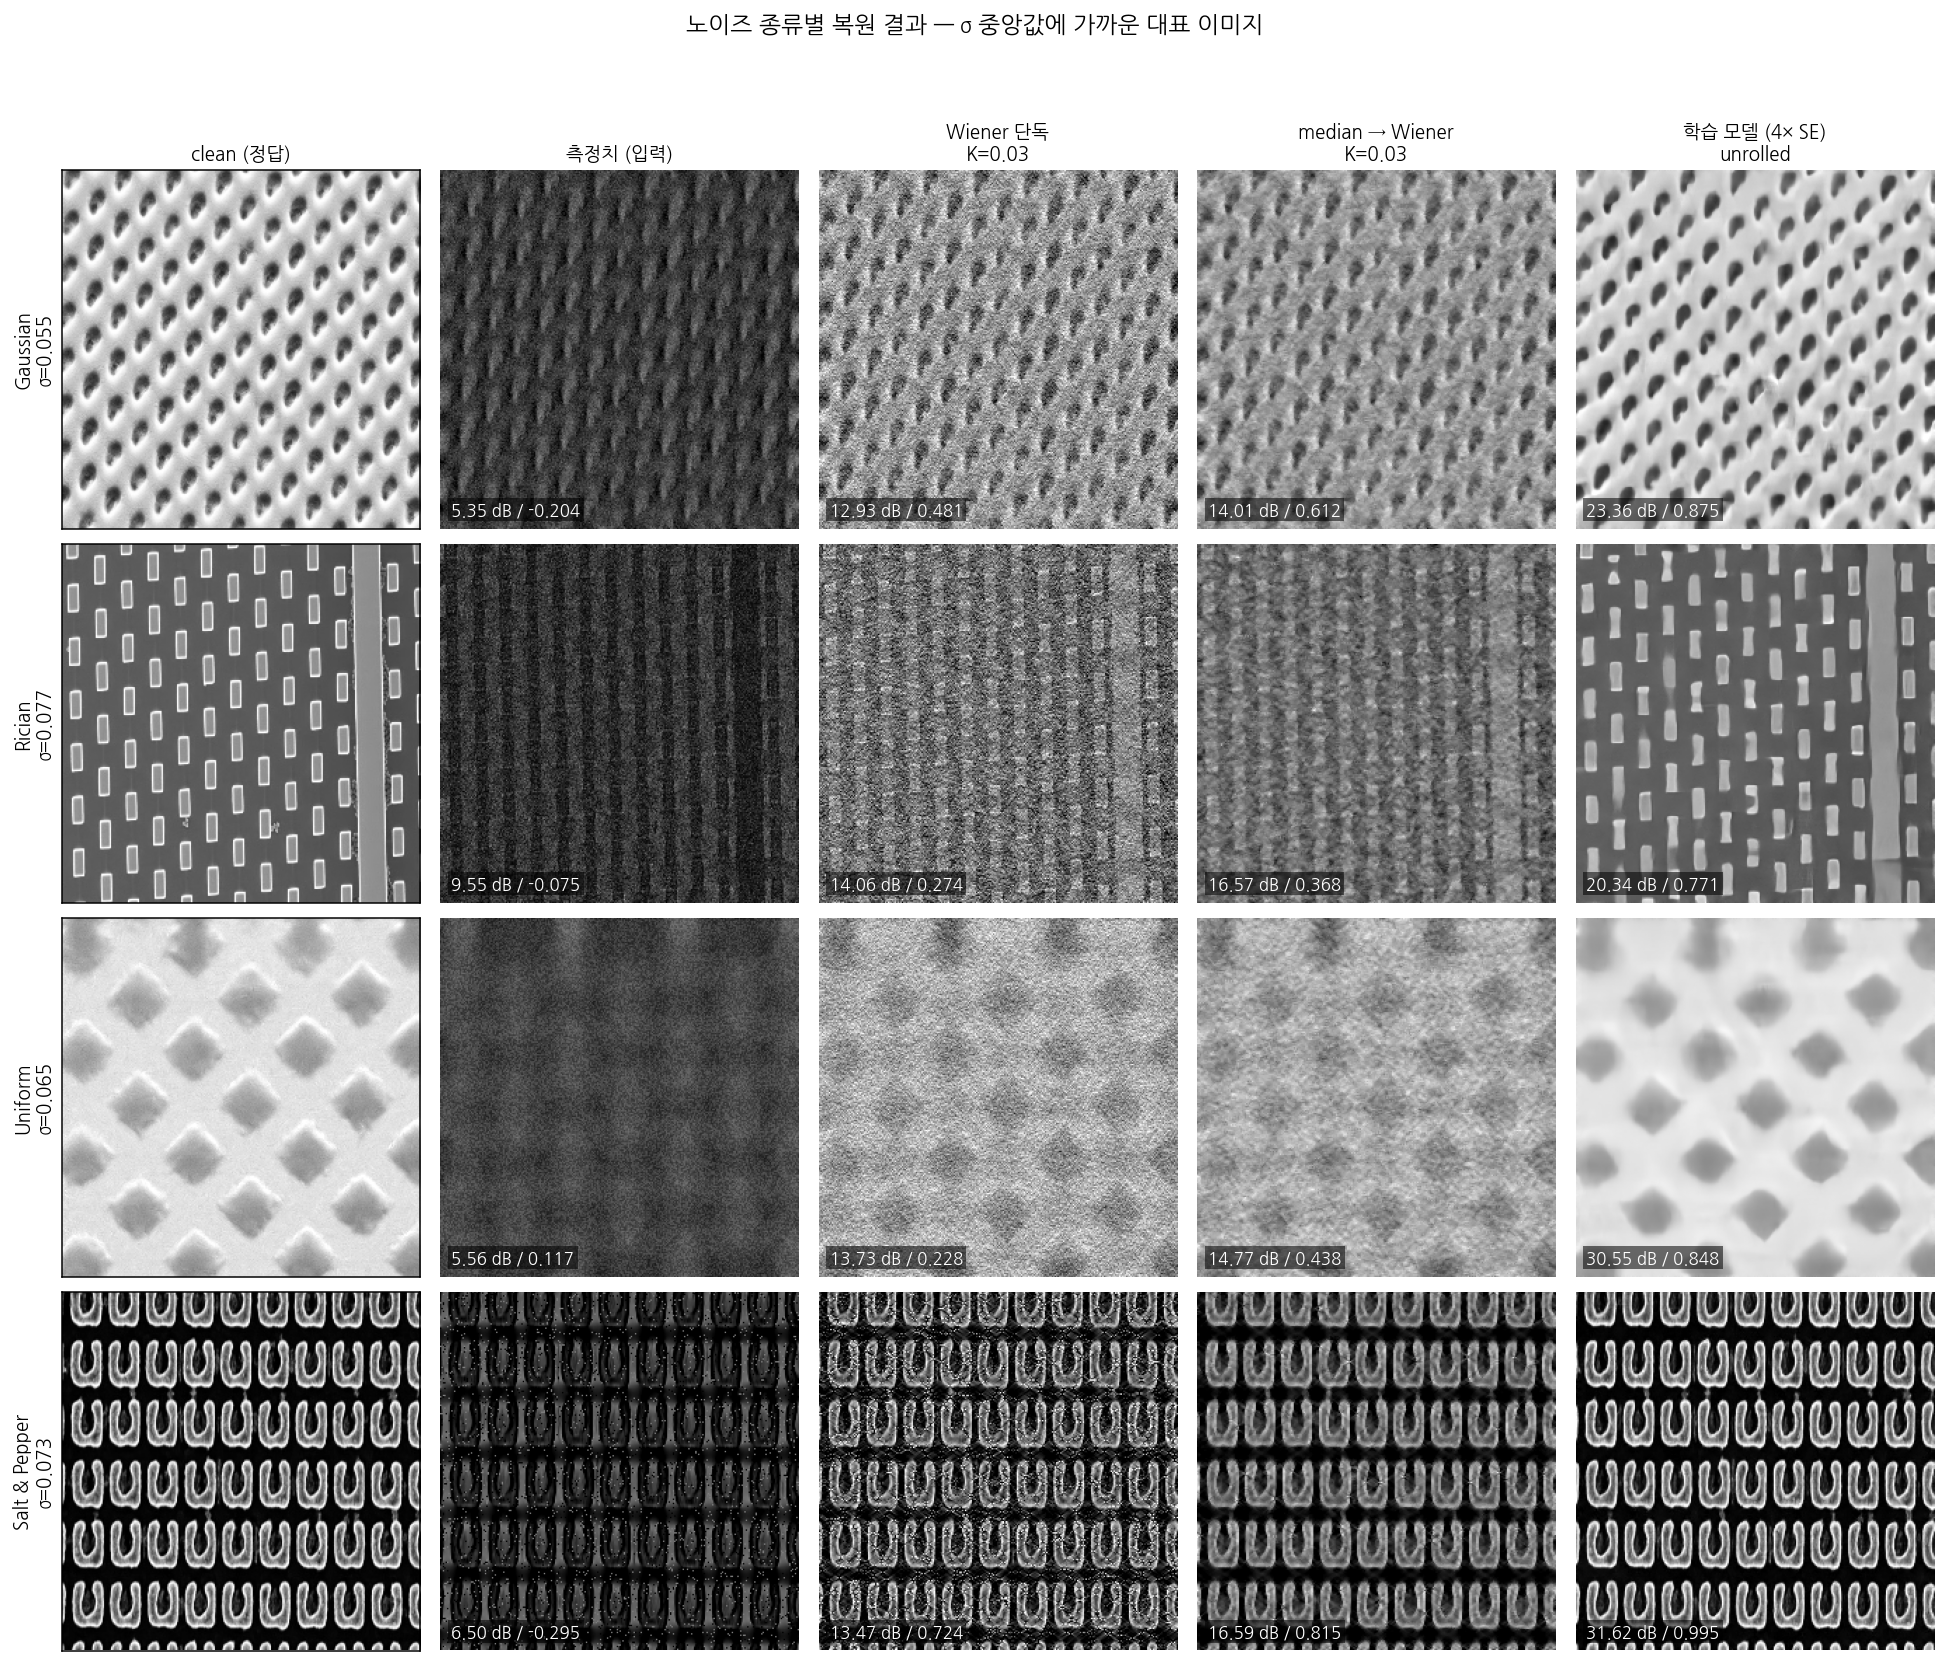

### day3_diff_zoom

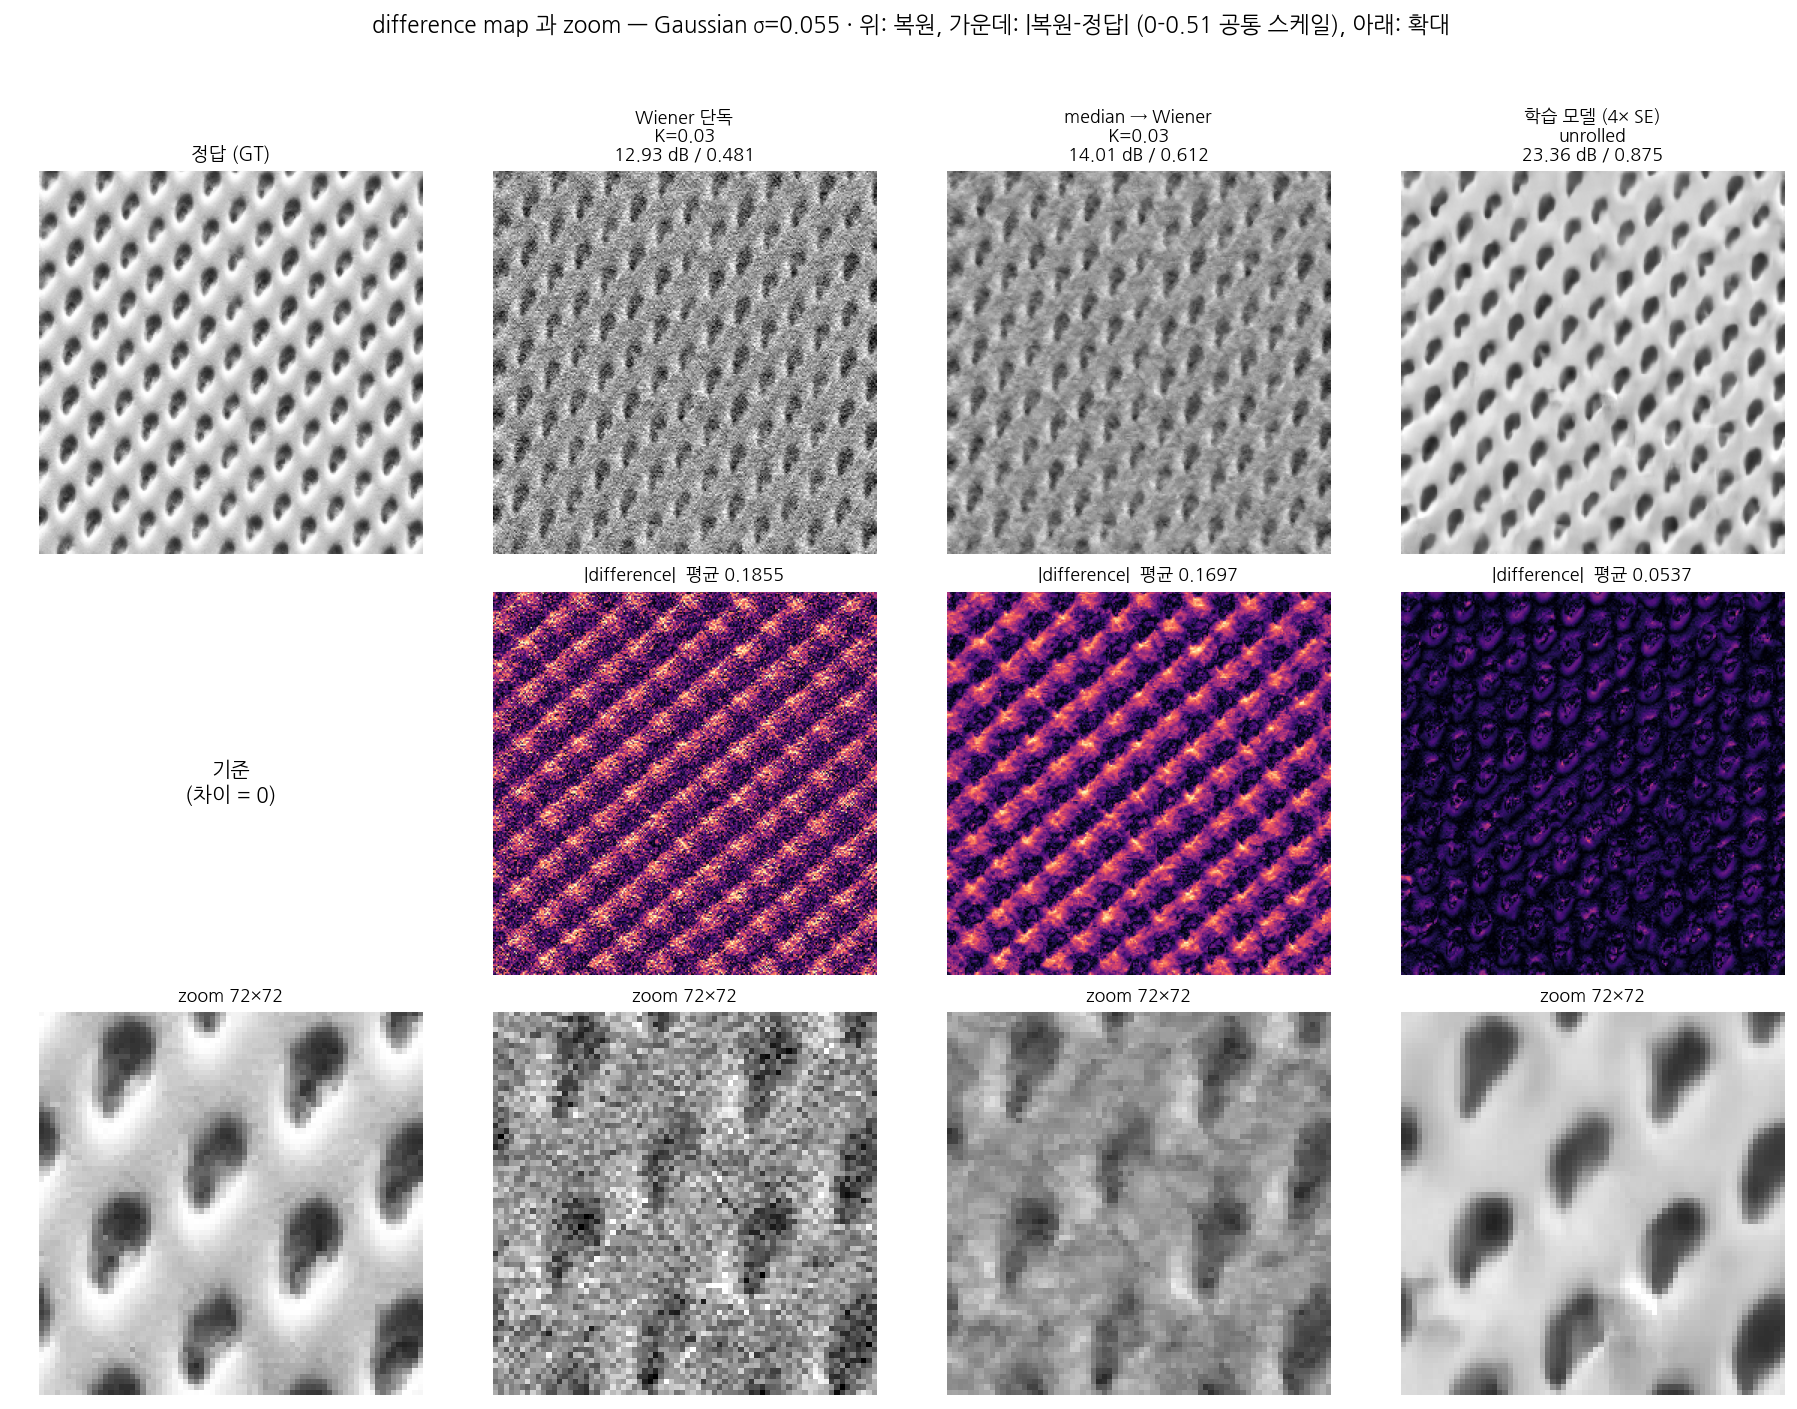

### day3_weakness

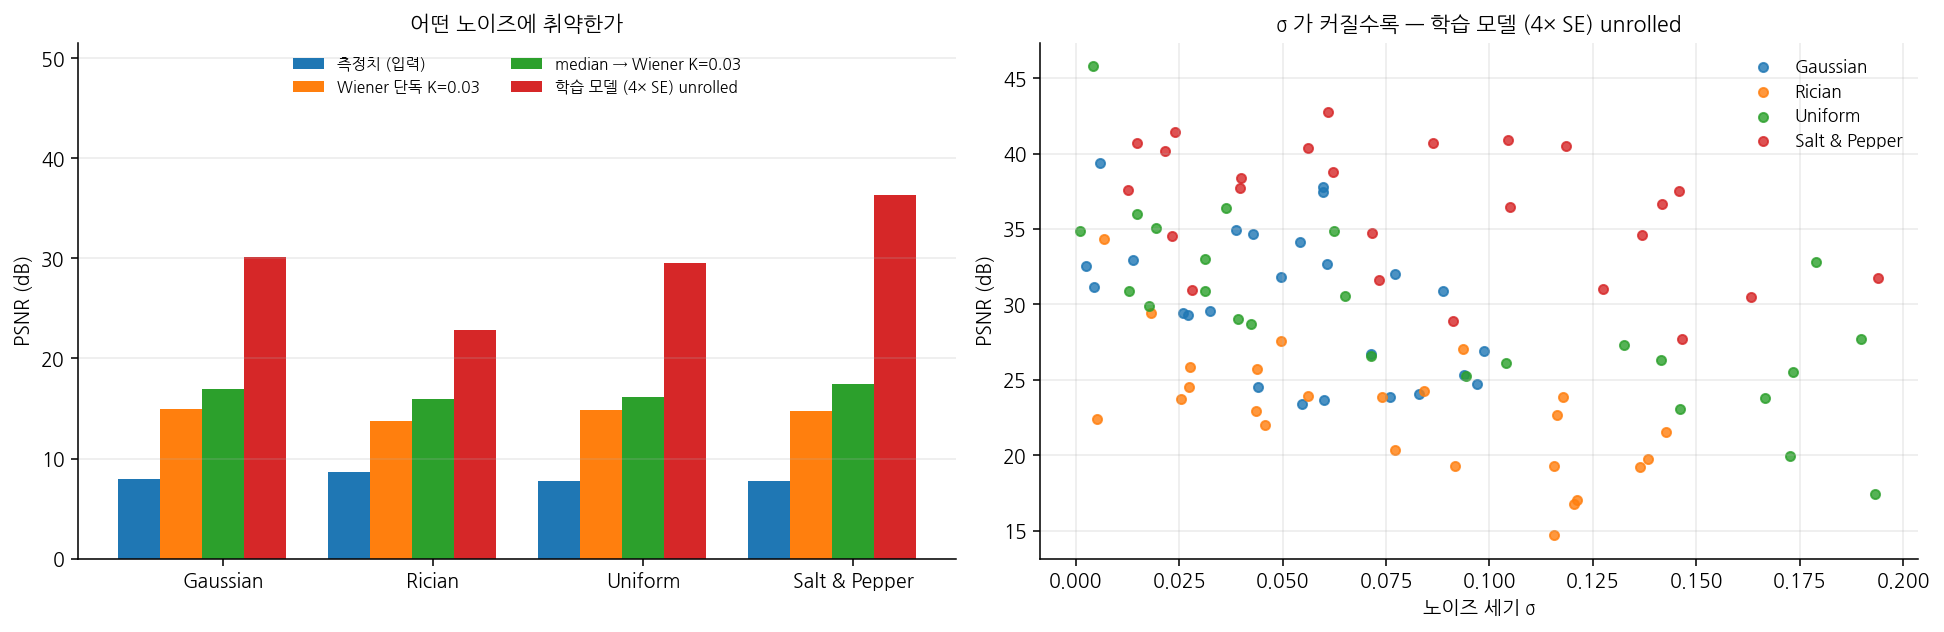

### day3_forward_chain

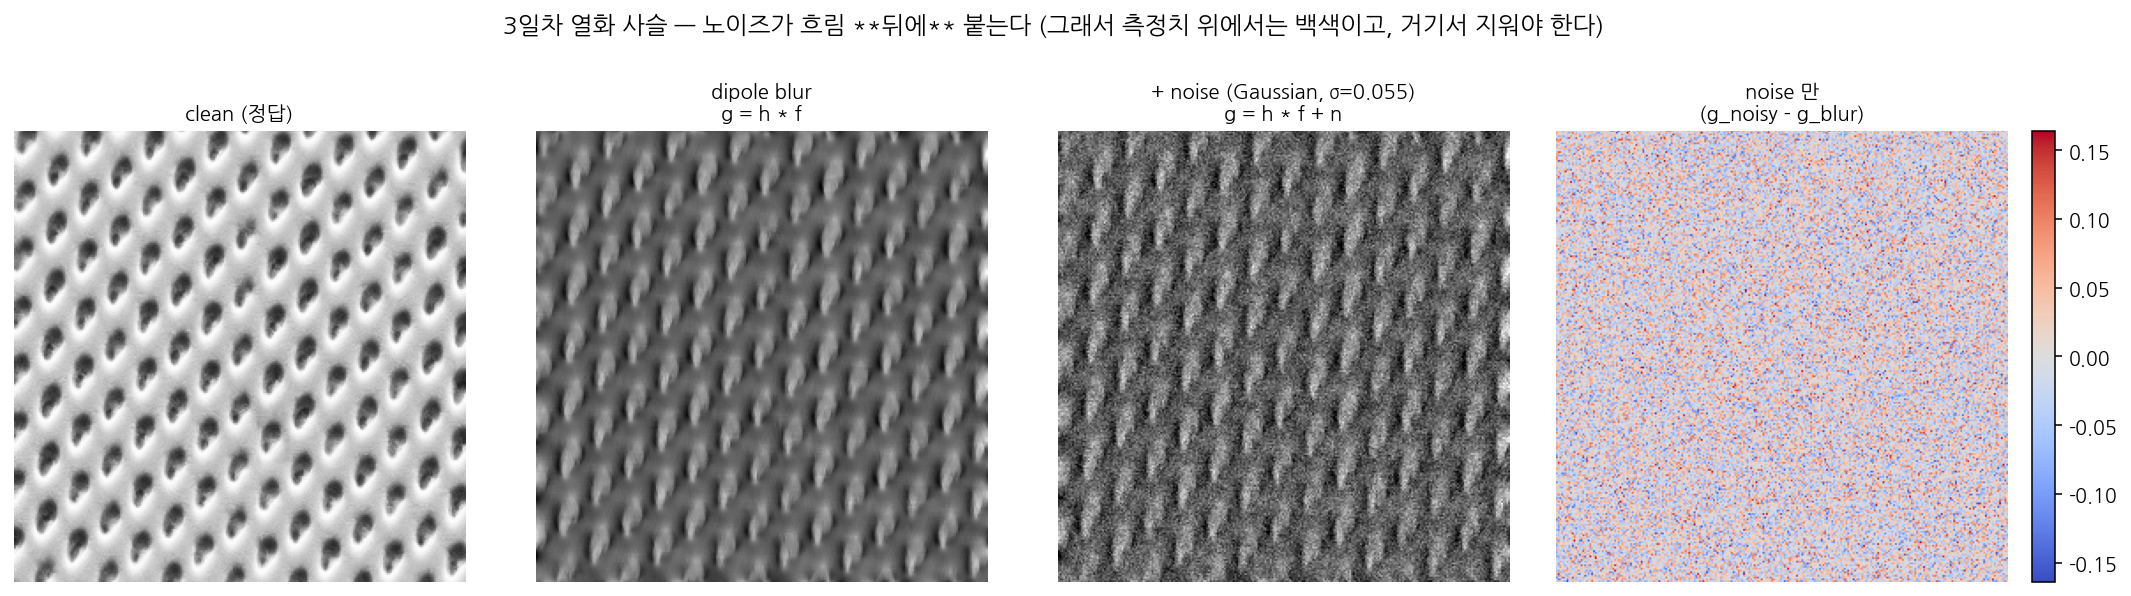

In [ ]:
import shutil
from IPython.display import Image, display, Markdown
DEST = REPO / "실습5" / "figures"; DEST.mkdir(parents=True, exist_ok=True)
for p in FIGDIR.glob("day3_*"): shutil.copy(p, DEST / p.name)

for stem in ("day3_methods_grid", "day3_diff_zoom", "day3_weakness", "day3_forward_chain"):
    display(Markdown(f"### {stem}")); display(Image(filename=str(FIGDIR / f"{stem}.png"), width=1150))


In [ ]:
!cd "{SRC}" && python analyze_types.py --data "{DATA_ROOT}" --per-image "{DEST}/day3_per_image.json" --out "{DEST}"


평가 대상: 학습 모델 (4× SE) unrolled   전체 29.70 dB

  어떤 type 의 이미지에 취약한가 (특징별 3등분)

무늬 조밀도  (낮음 → 높음)
    하위 1/3      55.8077     30.93 dB   (33장)
    중간          66.0387     30.06 dB   (33장)
    상위 1/3      80.6359     28.16 dB   (34장)
    차이 -2.77 dB   상관계수 -0.170

대비  (낮음 → 높음)
    하위 1/3       0.0795     32.23 dB   (33장)
    중간           0.1476     29.03 dB   (33장)
    상위 1/3       0.2435     27.90 dB   (34장)
    차이 -4.33 dB   상관계수 -0.299

에지 밀도  (낮음 → 높음)
    하위 1/3       0.0207     33.39 dB   (33장)
    중간           0.0430     30.08 dB   (33장)
    상위 1/3       0.0846     25.76 dB   (34장)
    차이 -7.63 dB   상관계수 -0.458

동적범위  (낮음 → 높음)
    하위 1/3       0.3904     31.84 dB   (33장)
    중간           0.6503     29.02 dB   (33장)
    상위 1/3       0.8535     28.29 dB   (34장)
    차이 -3.55 dB   상관계수 -0.248

  가장 못 살린 10장 — 무엇이 공통인가
noise                   σ    PSNR      조밀도      대비      에지
------------------------------------------------------------
rician              0.116   14.69     58.1  0.28

In [ ]:
!rm -rf /content/ds-practice /content/repo.zip
!curl -sL -o /content/repo.zip https://codeload.github.com/kithhooni-commits/ds-practice/zip/refs/heads/main
!cd /content && unzip -q repo.zip && mv ds-practice-main ds-practice


In [ ]:
!cd "{SRC}" && python train_lf_day3.py --data "{DATA_ROOT}" --features 48 --n-val 40 \
    --eval-only "/content/drive/MyDrive/ds_day3/0902-0907_lf_day3.ckpt"


run    : /content/ds-practice/실습5/runs/0902-1002_lf_day3
model  : drunet f48 (측정치 영역) | N2V ratio 0.02 window 5 | loss L1
학습   : 7268장 · 정답은 손실에 들어가지 않는다 (측정치 g 만)
amp    : torch.bfloat16

채점만 한다: 0902-0907_lf_day3.ckpt (ep 2, 학습 당시 val 17.37)

λ 를 어떻게 정하는가                        val PSNR  val SSIM
------------------------------------------------------
라벨 없이 (입력 σ) — 제출용                     17.90    0.4224
라벨 없이 (디노이징 뒤 잔여 σ)                    16.30    0.3394
(참고) val 에서 고른 고정 K=0.01               17.77    0.4182

제출용은 라벨 없이 고른 쪽이다. 고정 K 는 얼마나 손해인지 보려고 같이 잰다.

[label-free · λ 도 측정치에서 · 4× self-ensemble — test 100장]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25     19.48    0.5301
rician              25     16.90    0.4350
uniform             25     19.41    0.5852
salt_and_pepper     25     22.45    0.7669
ALL                100     19.56    0.5793

제출값(label-free) → PSNR 19.56  SSIM 0.5793


In [ ]:
NAME = "5조"          # ← 여기만 바꾸세요
PSNR, SSIM = 29.70, 0.8828

import shutil, subprocess, re
from pathlib import Path

# 1. 코드 다시 받기
!rm -rf /content/ds-practice /content/repo.zip
!curl -sL -o /content/repo.zip https://codeload.github.com/kithhooni-commits/ds-practice/zip/refs/heads/main
!cd /content && unzip -q repo.zip && mv ds-practice-main ds-practice

REPO   = Path("/content/ds-practice")
SRC    = REPO / "실습5" / "src" / "deconv"
DEST   = REPO / "실습5" / "figures"; DEST.mkdir(parents=True, exist_ok=True)
FIGDIR = Path("/content/figures")
DRIVE  = Path("/content/drive/MyDrive/ds_day3")
LF_CK  = "/content/drive/MyDrive/ds_day3/0902-0907_lf_day3.ckpt"

# 2. 그림 되돌려놓기 (zip 을 다시 풀면 사라진다)
for p in FIGDIR.glob("day3_*"):
    shutil.copy(p, DEST / p.name)
print("그림:", sorted(f.name for f in DEST.glob("day3_*")))

# 3. 발표 도구 준비
!pip -q install python-pptx
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib && mkdir -p ~/.cache/matplotlib

# 4. label-free 재평가 (λ 를 입력 기준으로 되돌린 뒤)
out = subprocess.run(
    ["python", "train_lf_day3.py", "--data", str(DATA_ROOT),
     "--features", "48", "--n-val", "40", "--eval-only", LF_CK],
    cwd=str(SRC), capture_output=True, text=True).stdout
print(out)
m = re.search(r"제출값\(label-free\) → PSNR\s+([\d.]+)\s+SSIM\s+([\d.]+)", out)
LFP, LFS = (float(m.group(1)), float(m.group(2))) if m else (0.0, 0.0)
print(f"label-free → {LFP:.2f} / {LFS:.4f}")

# 5. 발표 슬라이드
!cd "{SRC}" && python make_ppt3.py --psnr {PSNR} --ssim {SSIM} \
    --lf-psnr {LFP} --lf-ssim {LFS} --name "{NAME}"

# 6. Drive 저장
DRIVE.mkdir(parents=True, exist_ok=True)
for p in list(DEST.glob("day3_*")) + list((REPO / "실습5").glob("*.pptx")):
    shutil.copy(p, DRIVE / p.name)
    print(f"  {p.name:<44}{p.stat().st_size/1e6:>7.2f} MB  -> Drive")


그림: ['day3_combine.json', 'day3_diff_zoom.png', 'day3_forward_chain.png', 'day3_image_types.png', 'day3_methods_grid.png', 'day3_per_image.json', 'day3_results.json', 'day3_weakness.png']
run    : /content/ds-practice/실습5/runs/0902-1004_lf_day3
model  : drunet f48 (측정치 영역) | N2V ratio 0.02 window 5 | loss L1
학습   : 7268장 · 정답은 손실에 들어가지 않는다 (측정치 g 만)
amp    : torch.bfloat16

채점만 한다: 0902-0907_lf_day3.ckpt (ep 2, 학습 당시 val 17.37)

λ 를 어떻게 정하는가                        val PSNR  val SSIM
------------------------------------------------------
라벨 없이 (입력 σ) — 제출용                     17.90    0.4224
라벨 없이 (디노이징 뒤 잔여 σ)                    16.30    0.3394
(참고) val 에서 고른 고정 K=0.01               17.77    0.4182

제출용은 라벨 없이 고른 쪽이다. 고정 K 는 얼마나 손해인지 보려고 같이 잰다.

[label-free · λ 도 측정치에서 · 4× self-ensemble — test 100장]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25     19.48    0.5301
rician              25     16.90    0.4350
uniform         

## B. v1 을 이어서 더 학습  ★ 다른 런타임에서

v1 은 **수렴하지 않았다.** ep51 28.351 -> ep56 28.437 로 끝까지 오르고 있었다.
60 에폭이 모자랐던 것이다. `--init-model` 로 이어받아 코사인을 한 바퀴 더 돈다.
미세조정이므로 `--lr 1e-4` 로 낮춘다.

In [ ]:
CK = "/content/drive/MyDrive/ds_day3/0902-0418_deconv-measure_u_drunet_sig.ckpt"
import os; print("있음" if os.path.exists(CK) else "없음 — Drive 경로를 확인할 것")
!cd "{SRC}" && python train_deconv.py \
    --model unrolled --refine drunet --features 48 --unroll-iters 4 \
    --sigma-map --share-weights --init-model "{CK}" \
    --noise-model challenge --input measure \
    --epochs 60 --batch 4 --lr 1e-4 --clip-grad 1.0 --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag v1_more

In [ ]:
!rm -rf /content/ds-practice /content/repo.zip
!curl -sL -o /content/repo.zip https://codeload.github.com/kithhooni-commits/ds-practice/zip/refs/heads/main
!cd /content && unzip -q repo.zip && mv ds-practice-main ds-practice
from pathlib import Path
REPO = Path("/content/ds-practice"); SRC = REPO / "실습5" / "src" / "deconv"
RUNS = Path("/content/runs"); RUNS.mkdir(exist_ok=True)
CKM = "/content/drive/MyDrive/ds_day3/0902-0725_deconv-measure_v1_more.ckpt"


In [ ]:
!cd "{SRC}" && python train_deconv.py \
    --model unrolled --refine drunet --features 48 --unroll-iters 4 \
    --sigma-map --share-weights --init-model "{CKM}" \
    --noise-model challenge --input measure \
    --epochs 120 --batch 4 --lr 8e-5 --clip-grad 1.0 --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag long \
    --mirror /content/drive/MyDrive/ds_day3


sigma-map: 측정치의 널 원뿔에서 σ 를 읽어 매 단계 디노이저에 준다
run    : /content/runs/0902-1010_deconv-measure_long
이어서 학습: 0902-0725_deconv-measure_v1_more.ckpt (ep 56, val 28.85 dB / 0.8174)
model  : unrolled f48 | 입력 measure (1ch) | loss charbonnier
노이즈 : 1일차 4종 (gaussian/rician/uniform/salt&pepper) 을 흐림 뒤에 — 3일차 조건
학습   : 7268장 patch None batch 4 -> 1817 iter/ep, 120 ep
amp    : torch.bfloat16 | clip 1.0

  ep 00 it    0/1817 loss 0.04103
  ep 00 it  100/1817 loss 0.02857
  ep 00 it  200/1817 loss 0.02840
  ep 00 it  300/1817 loss 0.02896
  ep 00 it  400/1817 loss 0.02886
  ep 00 it  500/1817 loss 0.02927
  ep 00 it  600/1817 loss 0.02916
  ep 00 it  700/1817 loss 0.02909
  ep 00 it  800/1817 loss 0.02899
  ep 00 it  900/1817 loss 0.02909
  ep 00 it 1000/1817 loss 0.02898
  ep 00 it 1100/1817 loss 0.02896
  ep 00 it 1200/1817 loss 0.02892
  ep 00 it 1300/1817 loss 0.02887
  ep 00 it 1400/1817 loss 0.02889
  ep 00 it 1500/1817 loss 0.02893
  ep 00 it 1600/1817 loss 0.02889
  ep 00 it 1700/1817 loss 0.

In [ ]:
!rm -rf /content/ds-practice /content/repo.zip
!curl -sL -o /content/repo.zip https://codeload.github.com/kithhooni-commits/ds-practice/zip/refs/heads/main
!cd /content && unzip -q repo.zip && mv ds-practice-main ds-practice
from pathlib import Path
REPO = Path("/content/ds-practice"); SRC = REPO / "실습5" / "src" / "deconv"
D = "/content/drive/MyDrive/ds_day3"
LONG = f"{D}/0902-1010_deconv-measure_long.ckpt"
IT6  = f"{D}/0902-1011_deconv-measure_iter6.ckpt"


In [ ]:
!cd "{SRC}" && python eval_day3.py --data "{DATA_ROOT}" --ckpt "{IT6}" --self-ensemble


test_deconv_noise 100장 · g = dipole(f) + n

[입력 (blur + noise)]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25      7.91   -0.0418
rician              25      8.66   -0.0127
uniform             25      7.73    0.0095
salt_and_pepper     25      7.78   -0.0299
ALL                100      8.02   -0.0187

[unrolled (epoch 99)]
noise                n      PSNR      SSIM
------------------------------------------
gaussian            25     30.45    0.8898
rician              25     23.32    0.7671
uniform             25     29.81    0.9142
salt_and_pepper     25     37.70    0.9860
ALL                100     30.32    0.8893

제출값 →  PSNR_total 30.32   SSIM_total 0.8893


In [ ]:
LONG = "/content/drive/MyDrive/ds_day3/0902-1010_deconv-measure_long.ckpt"
IT6  = "/content/drive/MyDrive/ds_day3/0902-1011_deconv-measure_iter6.ckpt"
!cd "{SRC}" && python fuse_day3.py --data "{DATA_ROOT}" --ckpts "{LONG}" "{IT6}" --self-ensemble


val 100장 (튜닝) · test 100장 (채점)

  단독  unrolled (epoch 118)                         val  29.55 / 0.8290
  단독  unrolled (epoch 99)                          val  29.54 / 0.8287

[융합 무게 — val 100장]
설정                              PSNR      SSIM
----------------------------------------------
0.0 : 1.0                      29.54    0.8287
0.1 : 0.9                      29.58    0.8293
0.2 : 0.8                      29.61    0.8298
0.3 : 0.7                      29.63    0.8301
0.4 : 0.6                      29.64    0.8303
0.5 : 0.5                      29.65    0.8304
0.6 : 0.4                      29.65    0.8304
0.7 : 0.3                      29.63    0.8302
0.8 : 0.2                      29.62    0.8299
0.9 : 0.1                      29.59    0.8295
1.0 : 0.0                      29.55    0.8290
→ 선택: (np.float64(0.5), np.float64(0.5))   val 29.65 / 0.8304

[융합 (np.float64(0.5), np.float64(0.5)) — test 100장]
noise                n      PSNR      SSIM
-------------------------------------

In [ ]:
from pathlib import Path
REPO = Path("/content/ds-practice")
SRC  = REPO / "실습5" / "src" / "deconv"
DEST = REPO / "실습5" / "figures"; DEST.mkdir(parents=True, exist_ok=True)
FIGDIR = Path("/content/figures"); FIGDIR.mkdir(exist_ok=True)
DATA_ROOT = Path("/content/data/dataset")
IT6 = "/content/drive/MyDrive/ds_day3/0902-1011_deconv-measure_iter6.ckpt"
print("SRC 있음:", SRC.exists(), "| DATA 있음:", (DATA_ROOT / "test_deconv_noise").exists())


SRC 있음: True | DATA 있음: True


In [ ]:
!cd "{SRC}" && python figures_day3.py --data "{DATA_ROOT}" --ckpt "{IT6}" --self-ensemble --out "{FIGDIR}"



/content/ds-practice/실습5/src/deconv/figures_day3.py:143: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.9))
/content/ds-practice/실습5/src/deconv/figures_day3.py:143: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.9))
/content/ds-practice/실습5/src/deconv/figures_day3.py:143: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.9))
/content/ds-practice/실습5/src/deconv/figures_day3.py:143: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.9))
/content/ds-practice/실습5/src/deconv/figures_day3.py:143: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.9))
/content/ds-practice/실습5/src/deconv/figures_day3.py:143: UserWarning: Glyph 50676 (\N{HANG

In [ ]:
NAME = "본인이름"          # ← 여기만

import shutil
from pathlib import Path

# 최신 코드 (그림 각주 수정본)
!rm -rf /content/ds-practice /content/repo.zip
!curl -sL -o /content/repo.zip https://codeload.github.com/kithhooni-commits/ds-practice/zip/refs/heads/main
!cd /content && unzip -q repo.zip && mv ds-practice-main ds-practice

REPO   = Path("/content/ds-practice")
SRC    = REPO / "실습5" / "src" / "deconv"
DEST   = REPO / "실습5" / "figures"; DEST.mkdir(parents=True, exist_ok=True)
FIGDIR = Path("/content/figures")
DRIVE  = Path("/content/drive/MyDrive/ds_day3")
DATA_ROOT = Path("/content/data/dataset")

# 방금 만든 그림을 저장소로
for f in FIGDIR.glob("day3_*"):
    shutil.copy(f, DEST / f.name)
print("그림:", sorted(x.name for x in DEST.glob("day3_*")))

# 이미지 type 분석 (학습 모델 기준으로 다시)
!cd "{SRC}" && python analyze_types.py --data "{DATA_ROOT}" --per-image "{DEST}/day3_per_image.json" --out "{DEST}"

# 발표 자료
!pip -q install python-pptx
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1
!cd "{SRC}" && python make_ppt3.py --psnr 30.37 --ssim 0.8900 \
    --lf-psnr 19.56 --lf-ssim 0.5793 --name "{NAME}"

# Drive 저장
DRIVE.mkdir(parents=True, exist_ok=True)
for f in list(DEST.glob("day3_*")) + list((REPO / "실습5").glob("*.pptx")):
    shutil.copy(f, DRIVE / f.name)
    print(f"  {f.name:<44}{f.stat().st_size/1e6:>7.2f} MB")


그림: ['day3_combine.json', 'day3_diff_zoom.png', 'day3_forward_chain.png', 'day3_image_types.png', 'day3_methods_grid.png', 'day3_per_image.json', 'day3_results.json', 'day3_weakness.png']
평가 대상: 학습 모델 (4× SE) unrolled   전체 30.32 dB

  어떤 type 의 이미지에 취약한가 (특징별 3등분)

무늬 조밀도  (낮음 → 높음)
    하위 1/3      55.8077     31.75 dB   (33장)
    중간          66.0387     30.63 dB   (33장)
    상위 1/3      80.6359     28.63 dB   (34장)
    차이 -3.11 dB   상관계수 -0.179

대비  (낮음 → 높음)
    하위 1/3       0.0795     32.91 dB   (33장)
    중간           0.1476     29.53 dB   (33장)
    상위 1/3       0.2435     28.57 dB   (34장)
    차이 -4.34 dB   상관계수 -0.279

에지 밀도  (낮음 → 높음)
    하위 1/3       0.0207     34.03 dB   (33장)
    중간           0.0430     30.80 dB   (33장)
    상위 1/3       0.0846     26.25 dB   (34장)
    차이 -7.78 dB   상관계수 -0.442

동적범위  (낮음 → 높음)
    하위 1/3       0.3904     32.48 dB   (33장)
    중간           0.6503     29.50 dB   (33장)
    상위 1/3       0.8535     29.02 dB   (34장)
    차이 -3.47 dB   상관계수 -0.234

  가장 

In [ ]:
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1
!fc-cache -f > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib && mkdir -p ~/.cache/matplotlib
import matplotlib.font_manager as fm
fm.fontManager.__init__()
have = sorted({f.name for f in fm.fontManager.ttflist if "Nanum" in f.name})
print("한글 폰트:", have if have else "없음 ← 이러면 또 깨진다")


한글 폰트: ['NanumBarunGothic', 'NanumGothic', 'NanumGothicCoding', 'NanumMyeongjo', 'NanumSquare', 'NanumSquareRound']


In [ ]:
!cd "{SRC}" && python figures_day3.py --data "{DATA_ROOT}" --ckpt "{IT6}" --self-ensemble --out "{FIGDIR}"
!cd "{SRC}" && python analyze_types.py --data "{DATA_ROOT}" --per-image "{DEST}/day3_per_image.json" --out "{DEST}"


저장: /content/figures/day3_forward_chain.png
저장: /content/figures/day3_methods_grid.png
저장: /content/figures/day3_diff_zoom.png
저장: /content/figures/day3_weakness.png
저장: /content/figures/day3_per_image.json
평가 대상: 학습 모델 (4× SE) unrolled   전체 30.32 dB

  어떤 type 의 이미지에 취약한가 (특징별 3등분)

무늬 조밀도  (낮음 → 높음)
    하위 1/3      55.8077     31.75 dB   (33장)
    중간          66.0387     30.63 dB   (33장)
    상위 1/3      80.6359     28.63 dB   (34장)
    차이 -3.11 dB   상관계수 -0.179

대비  (낮음 → 높음)
    하위 1/3       0.0795     32.91 dB   (33장)
    중간           0.1476     29.53 dB   (33장)
    상위 1/3       0.2435     28.57 dB   (34장)
    차이 -4.34 dB   상관계수 -0.279

에지 밀도  (낮음 → 높음)
    하위 1/3       0.0207     34.03 dB   (33장)
    중간           0.0430     30.80 dB   (33장)
    상위 1/3       0.0846     26.25 dB   (34장)
    차이 -7.78 dB   상관계수 -0.442

동적범위  (낮음 → 높음)
    하위 1/3       0.3904     32.48 dB   (33장)
    중간           0.6503     29.50 dB   (33장)
    상위 1/3       0.8535     29.02 dB   (34장)
    차이 -3.47 dB  

In [ ]:
import shutil
for f in FIGDIR.glob("day3_*"): shutil.copy(f, DEST / f.name)


In [ ]:
!cd "{SRC}" && python make_ppt3.py --psnr 30.37 --ssim 0.8900 \
    --lf-psnr 19.56 --lf-ssim 0.5793 --name "본인이름"


슬라이드 19장 → /content/ds-practice/실습5/실습5_day3_발표.pptx


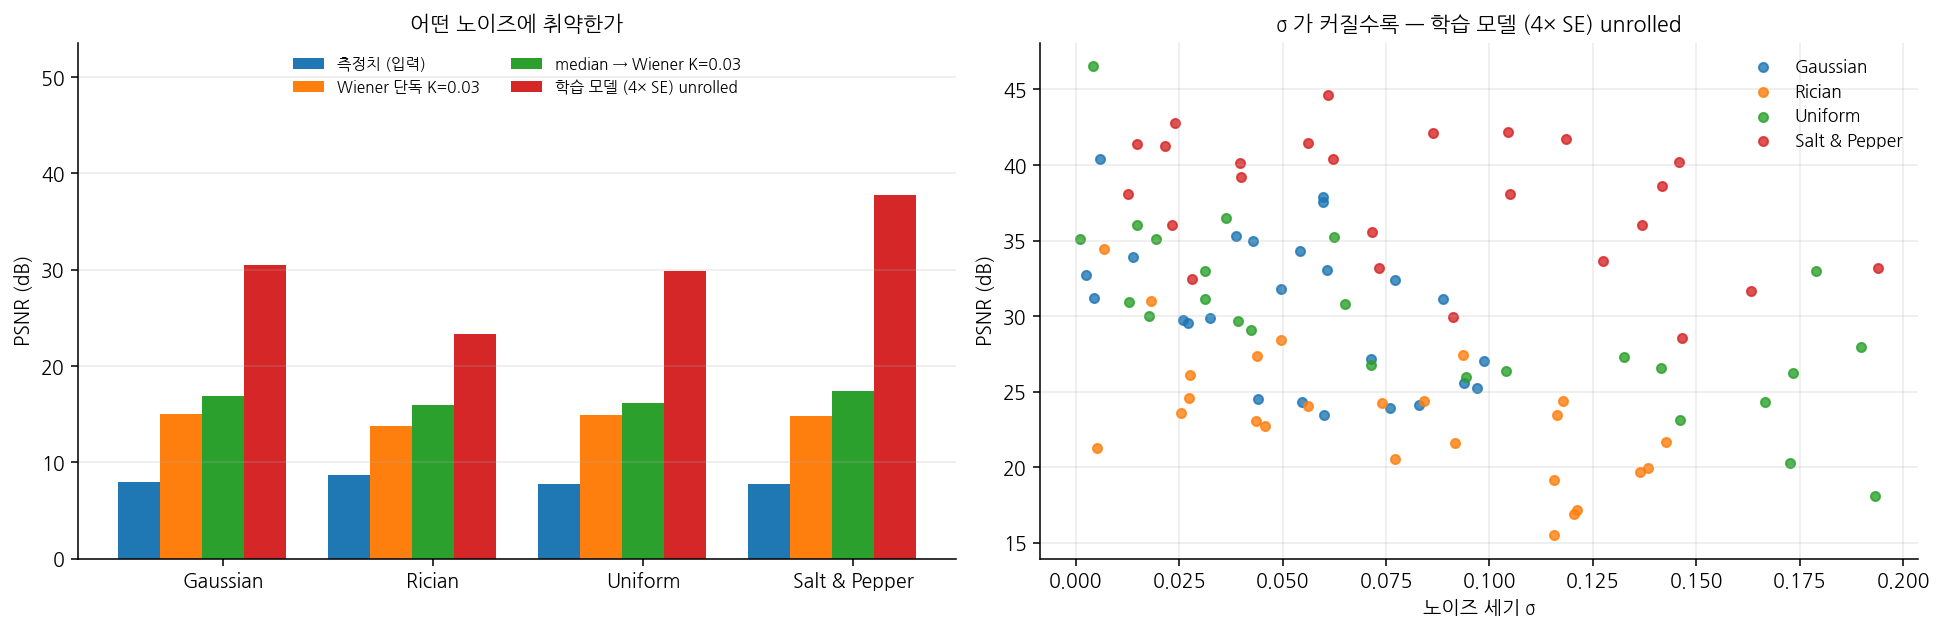

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/figures/day3_weakness.png", width=1100))


In [ ]:
!cd "/content/ds-practice" && git pull 2>/dev/null || (rm -rf /content/ds-practice /content/repo.zip && curl -sL -o /content/repo.zip https://codeload.github.com/kithhooni-commits/ds-practice/zip/refs/heads/main && cd /content && unzip -q repo.zip && mv ds-practice-main ds-practice)


In [ ]:
import shutil
from pathlib import Path
REPO = Path("/content/ds-practice"); SRC = REPO / "실습5" / "src" / "deconv"
DEST = REPO / "실습5" / "figures"; DEST.mkdir(parents=True, exist_ok=True)
for f in Path("/content/figures").glob("day3_*"): shutil.copy(f, DEST / f.name)
print(sorted(x.name for x in DEST.glob("day3_*")))


['day3_combine.json', 'day3_diff_zoom.png', 'day3_forward_chain.png', 'day3_image_types.png', 'day3_methods_grid.png', 'day3_per_image.json', 'day3_results.json', 'day3_weakness.png']


In [ ]:
!cd "{SRC}" && python make_ppt3.py --psnr 30.37 --ssim 0.8900 \
    --lf-psnr 19.56 --lf-ssim 0.5793 --name "본인이름"


슬라이드 19장 → /content/ds-practice/실습5/실습5_day3_발표.pptx


In [ ]:
import shutil
from pathlib import Path
DRIVE = Path("/content/drive/MyDrive/ds_day3"); DRIVE.mkdir(parents=True, exist_ok=True)
REPO = Path("/content/ds-practice")
for f in list((REPO / "실습5" / "figures").glob("day3_*")) + list((REPO / "실습5").glob("*.pptx")):
    shutil.copy(f, DRIVE / f.name)
    print(f"  {f.name:<44}{f.stat().st_size/1e6:>7.2f} MB")


  day3_results.json                              0.00 MB
  day3_per_image.json                            0.03 MB
  day3_image_types.png                           0.12 MB
  day3_weakness.png                              0.09 MB
  day3_forward_chain.png                         1.32 MB
  day3_diff_zoom.png                             1.97 MB
  day3_combine.json                              0.01 MB
  day3_methods_grid.png                          3.32 MB
  실습5_denoising_발표.pptx                          7.45 MB
  실습5_day3_발표.pptx                               6.64 MB
  실습5_day3_발표_v2.pptx                            5.08 MB
  실습5_deconvolution_발표.pptx                      0.62 MB
